# 01. EDA - Abalone Regression

이 노트북의 목적은 단순히 `head()`와 `describe()`를 확인하는 것에서 끝내지 않고, 이후 baseline/modeling 단계에서 바로 사용할 판단 근거를 남기는 것입니다.

- 원본 train/test/schema 검증
- `Rings` 타깃 분포와 RMSLE 관점의 주의점 확인
- 범주형 `Sex`와 수치형 피처의 분포 및 train/test drift 확인
- 상관관계, 이상치, 물리적으로 의미 있는 파생 피처 후보 정리


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import ks_2samp
except ImportError:
    ks_2samp = None

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

COLUMN_RENAME = {
    "Whole weight": "Whole_weight",
    "Whole weight.1": "Shucked_weight",
    "Whole weight.2": "Viscera_weight",
    "Shell weight": "Shell_weight",
}
TARGET = "Rings"
ID_COL = "id"
CAT_COLS = ["Sex"]


## 1. Load Data

Kaggle CSV의 `Whole weight.1`, `Whole weight.2`는 이름만 보면 중복 변수처럼 보이지만 각각 shucked/viscera weight에 대응합니다. EDA 초반에 의미 있는 이름으로 바꿔두면 이후 해석 실수를 줄일 수 있습니다.


In [2]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

train = train_raw.rename(columns=COLUMN_RENAME).copy()
test = test_raw.rename(columns=COLUMN_RENAME).copy()

num_cols = [c for c in train.select_dtypes(include="number").columns if c not in [ID_COL, TARGET]]
feature_cols = CAT_COLS + num_cols

print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"submission: {sample_submission.shape}")

display(train.head())
display(test.head())


train: (90615, 10)
test : (60411, 9)
submission: (60411, 2)


,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,F,0.5500,0.4300,0.1500,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.6300,0.4900,0.1450,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.1600,0.1100,0.0250,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.5950,0.4750,0.1500,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.5550,0.4250,0.1300,0.7820,0.3695,0.1600,0.1975,9


,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,90615,M,0.6450,0.4750,0.1550,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.5800,0.4600,0.1600,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.5600,0.4200,0.1400,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.5700,0.4900,0.1450,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.4150,0.3250,0.1100,0.3580,0.1575,0.0670,0.1050


## 2. Basic Quality Checks

회귀 모델링 전에는 결측, 중복, id 겹침, train/test 스키마 차이를 먼저 고정합니다. `id`는 식별자이므로 모델 피처에서 제외합니다.


In [3]:
def summarize_frame(df: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series(
        {
            "rows": len(df),
            "columns": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
            "duplicated_rows": int(df.duplicated().sum()),
            "id_unique": bool(df[ID_COL].is_unique),
        },
        name=name,
    )

basic_summary = pd.concat(
    [summarize_frame(train, "train"), summarize_frame(test, "test")],
    axis=1,
)

schema_check = pd.DataFrame(
    {
        "train_dtype": train.dtypes.astype(str),
        "test_dtype": test.dtypes.astype(str),
    }
)

id_overlap = len(set(train[ID_COL]).intersection(test[ID_COL]))

print(f"train/test id overlap: {id_overlap:,}")
display(basic_summary)
display(schema_check)


train/test id overlap: 0


,train,test
rows,90615,60411
columns,10,9
missing_cells,0,0
duplicated_rows,0,0
id_unique,True,True


,train_dtype,test_dtype
Diameter,float64,float64
Height,float64,float64
Length,float64,float64
Rings,int64,NaN
Sex,str,str
Shell_weight,float64,float64
Shucked_weight,float64,float64
Viscera_weight,float64,float64
Whole_weight,float64,float64
id,int64,int64


In [4]:
summary_cols = [c for c in num_cols + [TARGET] if c in train.columns]
train_summary = train[summary_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

test_summary = test[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print("Train numeric summary")
display(train_summary)
print("Test numeric summary")
display(test_summary)


Train numeric summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Length,90615.0000,0.5171,0.1182,0.0750,0.1900,0.2800,0.4450,0.5450,0.6000,0.6800,0.7200,0.8150
Diameter,90615.0000,0.4017,0.0980,0.0550,0.1350,0.2100,0.3450,0.4250,0.4700,0.5350,0.5700,0.6500
Height,90615.0000,0.1355,0.0380,0.0000,0.0450,0.0700,0.1100,0.1400,0.1600,0.1950,0.2150,1.1300
Whole_weight,90615.0000,0.7890,0.4577,0.0020,0.0320,0.1075,0.4190,0.7995,1.0675,1.6185,1.9384,2.8255
Shucked_weight,90615.0000,0.3408,0.2044,0.0010,0.0125,0.0430,0.1775,0.3300,0.4630,0.7105,0.8969,1.4880
Viscera_weight,90615.0000,0.1694,0.1009,0.0005,0.0065,0.0230,0.0865,0.1660,0.2325,0.3555,0.4220,0.7600
Shell_weight,90615.0000,0.2259,0.1302,0.0015,0.0100,0.0310,0.1200,0.2250,0.3050,0.4600,0.5700,1.0050
Rings,90615.0000,9.6968,3.1762,1.0000,4.0000,5.0000,8.0000,9.0000,11.0000,16.0000,20.0000,29.0000


Test numeric summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Length,60411.0000,0.5174,0.1176,0.0750,0.1950,0.2800,0.4500,0.5450,0.6000,0.6750,0.7200,0.8000
Diameter,60411.0000,0.4020,0.0975,0.0550,0.1400,0.2100,0.3450,0.4250,0.4700,0.5350,0.5700,0.6500
Height,60411.0000,0.1358,0.0382,0.0000,0.0450,0.0700,0.1100,0.1400,0.1600,0.1950,0.2150,1.0950
Whole_weight,60411.0000,0.7901,0.4576,0.0020,0.0330,0.1075,0.4195,0.8015,1.0700,1.6185,1.9455,2.8255
Shucked_weight,60411.0000,0.3412,0.2042,0.0010,0.0125,0.0440,0.1785,0.3290,0.4645,0.7110,0.8895,1.4880
Viscera_weight,60411.0000,0.1694,0.1007,0.0005,0.0065,0.0235,0.0865,0.1660,0.2325,0.3555,0.4220,0.6415
Shell_weight,60411.0000,0.2261,0.1298,0.0015,0.0100,0.0325,0.1200,0.2250,0.3050,0.4600,0.5650,1.0040


## 3. Target Distribution

대회 평가지표가 RMSLE이므로 `Rings`의 오른쪽 꼬리와 작은 값 구간을 함께 봐야 합니다. `log1p(Rings)`로 학습하는 전략을 baseline에서 비교할 가치가 있습니다.


,Rings
count,90615.0000
mean,9.6968
std,3.1762
min,1.0000
1%,4.0000
5%,5.0000
10%,6.0000
25%,8.0000
50%,9.0000
75%,11.0000


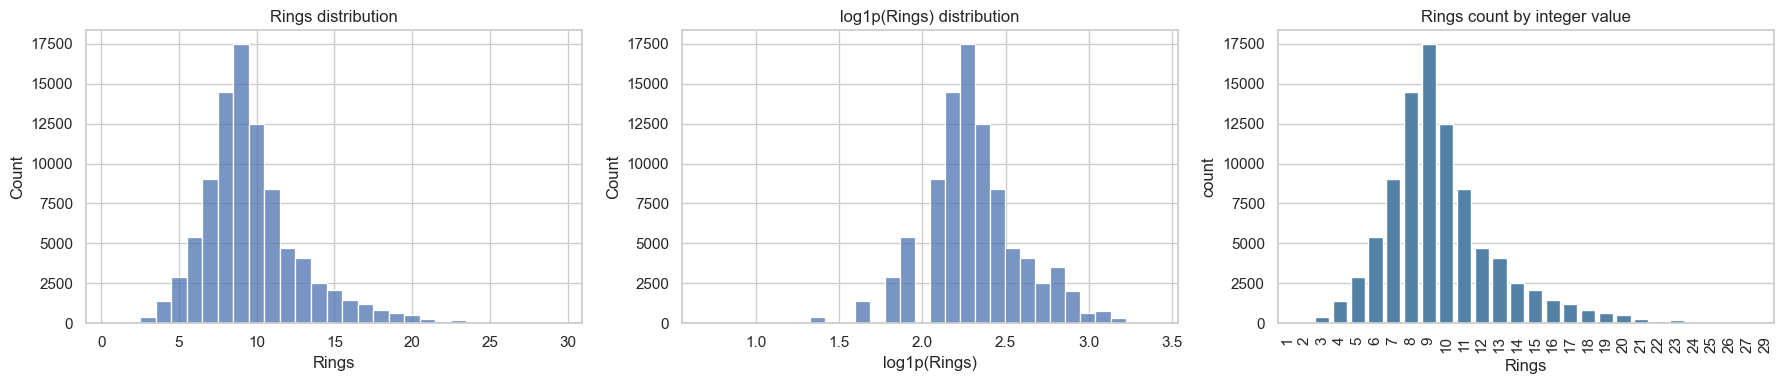

In [5]:
target_summary = train[TARGET].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).to_frame("Rings")
target_summary.loc["skew", "Rings"] = train[TARGET].skew()
target_summary.loc["kurtosis", "Rings"] = train[TARGET].kurtosis()
target_summary.loc["mean_age_years", "Rings"] = train[TARGET].mean() + 1.5

display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(train[TARGET], bins=np.arange(train[TARGET].min(), train[TARGET].max() + 2) - 0.5, ax=axes[0])
axes[0].set_title("Rings distribution")
axes[0].set_xlabel("Rings")

sns.histplot(np.log1p(train[TARGET]), bins=30, ax=axes[1])
axes[1].set_title("log1p(Rings) distribution")
axes[1].set_xlabel("log1p(Rings)")

ring_counts = train[TARGET].value_counts().sort_index()
sns.barplot(x=ring_counts.index, y=ring_counts.values, color="steelblue", ax=axes[2])
axes[2].set_title("Rings count by integer value")
axes[2].set_xlabel("Rings")
axes[2].set_ylabel("count")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## 4. Categorical Feature: Sex

`Sex`는 `M`, `F`, `I` 세 범주의 명목형 변수입니다. 범주별 타깃 위치가 다르므로 one-hot encoding을 기본 후보로 두는 것이 자연스럽습니다.


,train_ratio,test_ratio,train_count,test_count
Sex,,,,
F,0.2924,0.2878,26495,17387
I,0.3652,0.3682,33093,22241
M,0.3424,0.3440,31027,20783


,count,mean,std,median,min,max
Sex,,,,,,
F,26495,11.1614,3.0216,10.0000,1,29
I,33093,7.5336,2.1315,7.0000,1,29
M,31027,10.7534,2.9803,10.0000,1,29


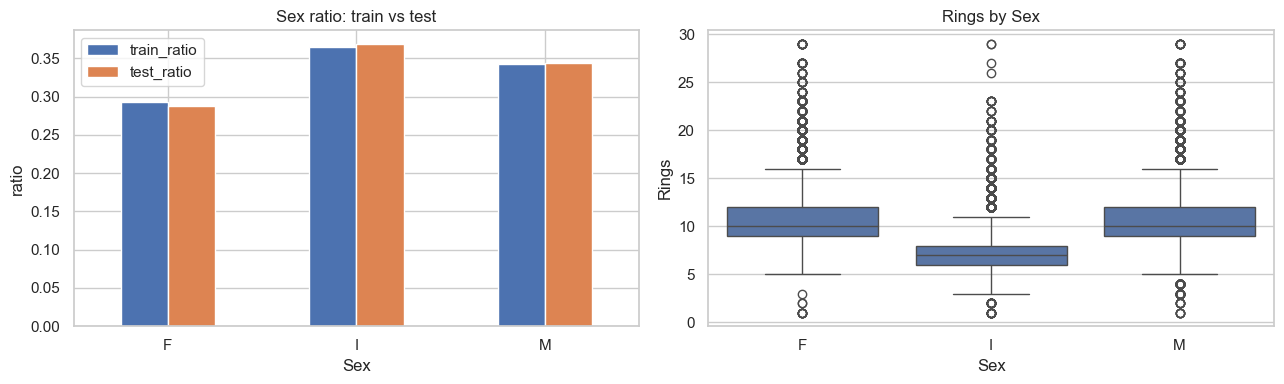

In [6]:
sex_distribution = pd.concat(
    [
        train["Sex"].value_counts(normalize=True).rename("train_ratio"),
        test["Sex"].value_counts(normalize=True).rename("test_ratio"),
        train["Sex"].value_counts().rename("train_count"),
        test["Sex"].value_counts().rename("test_count"),
    ],
    axis=1,
).sort_index()

sex_target = train.groupby("Sex")[TARGET].agg(["count", "mean", "std", "median", "min", "max"]).sort_index()

display(sex_distribution)
display(sex_target)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sex_distribution[["train_ratio", "test_ratio"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Sex ratio: train vs test")
axes[0].set_ylabel("ratio")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=train, x="Sex", y=TARGET, order=sorted(train["Sex"].unique()), ax=axes[1])
axes[1].set_title("Rings by Sex")

plt.tight_layout()
plt.show()


## 5. Numeric Feature Distributions

수치형 피처는 train/test 분포가 비슷한지, 극단값이 있는지, 단조적인 물리 관계가 유지되는지 확인합니다.


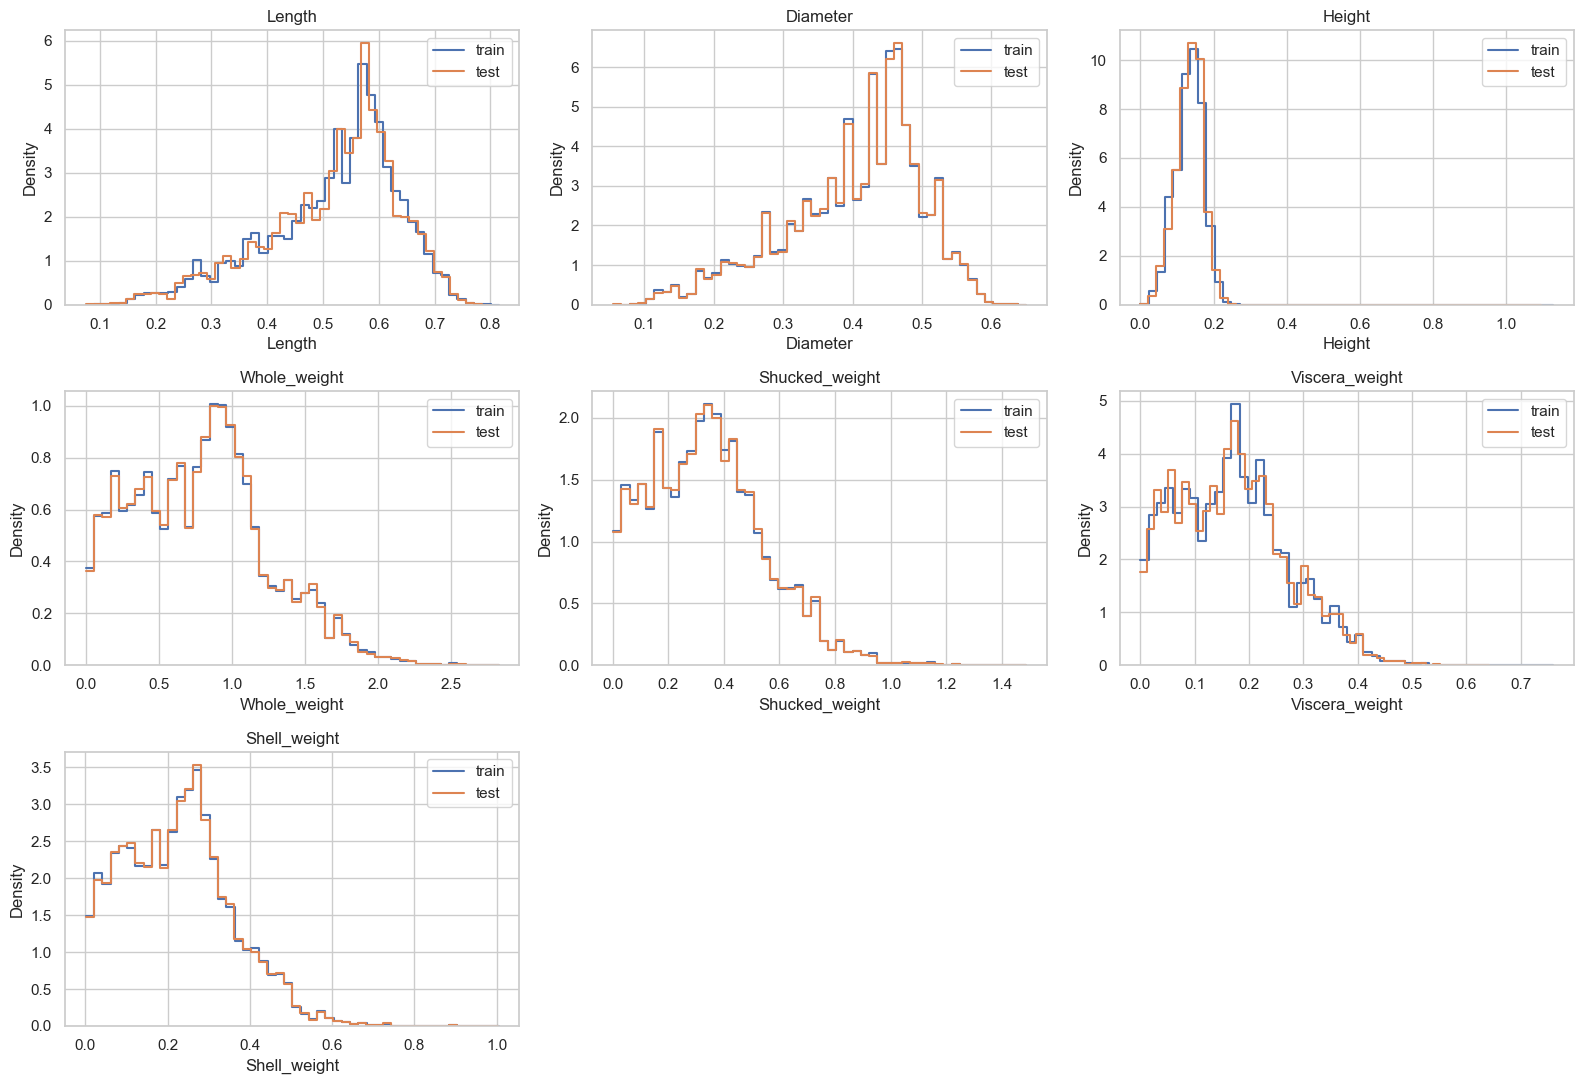

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(train[col], bins=50, stat="density", element="step", fill=False, label="train", ax=ax)
    sns.histplot(test[col], bins=50, stat="density", element="step", fill=False, label="test", ax=ax)
    ax.set_title(col)
    ax.legend()

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


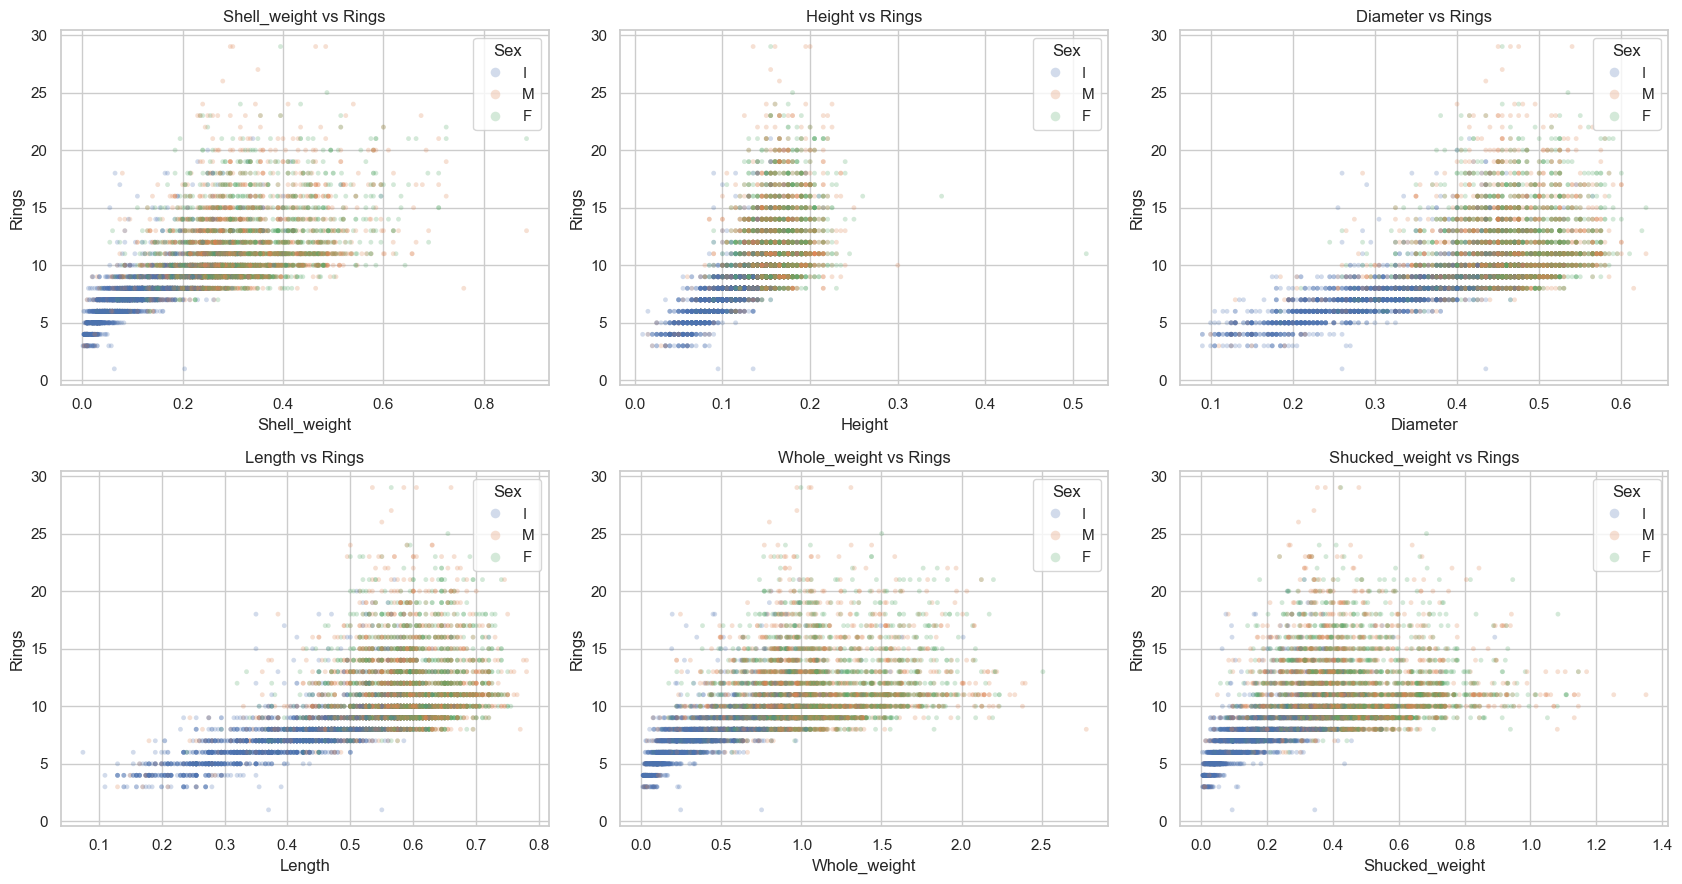

In [8]:
sample = train.sample(n=min(8_000, len(train)), random_state=RANDOM_STATE)
strong_cols = ["Shell_weight", "Height", "Diameter", "Length", "Whole_weight", "Shucked_weight"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flatten(), strong_cols):
    sns.scatterplot(data=sample, x=col, y=TARGET, hue="Sex", alpha=0.25, s=12, linewidth=0, ax=ax)
    ax.set_title(f"{col} vs Rings")
    ax.legend(title="Sex", loc="best", markerscale=2)

plt.tight_layout()
plt.show()


## 6. Correlation Structure

전복의 길이·무게 변수들은 서로 강하게 연동됩니다. 트리 기반 모델은 그대로 사용해도 비교적 견고하지만, 선형 모델에서는 정규화나 규제, 또는 파생 피처 선택이 중요합니다.


,corr_with_Rings
Shell_weight,0.6948
Height,0.6658
Diameter,0.6368
Length,0.6238
Whole_weight,0.6173
Viscera_weight,0.5890
Shucked_weight,0.5151


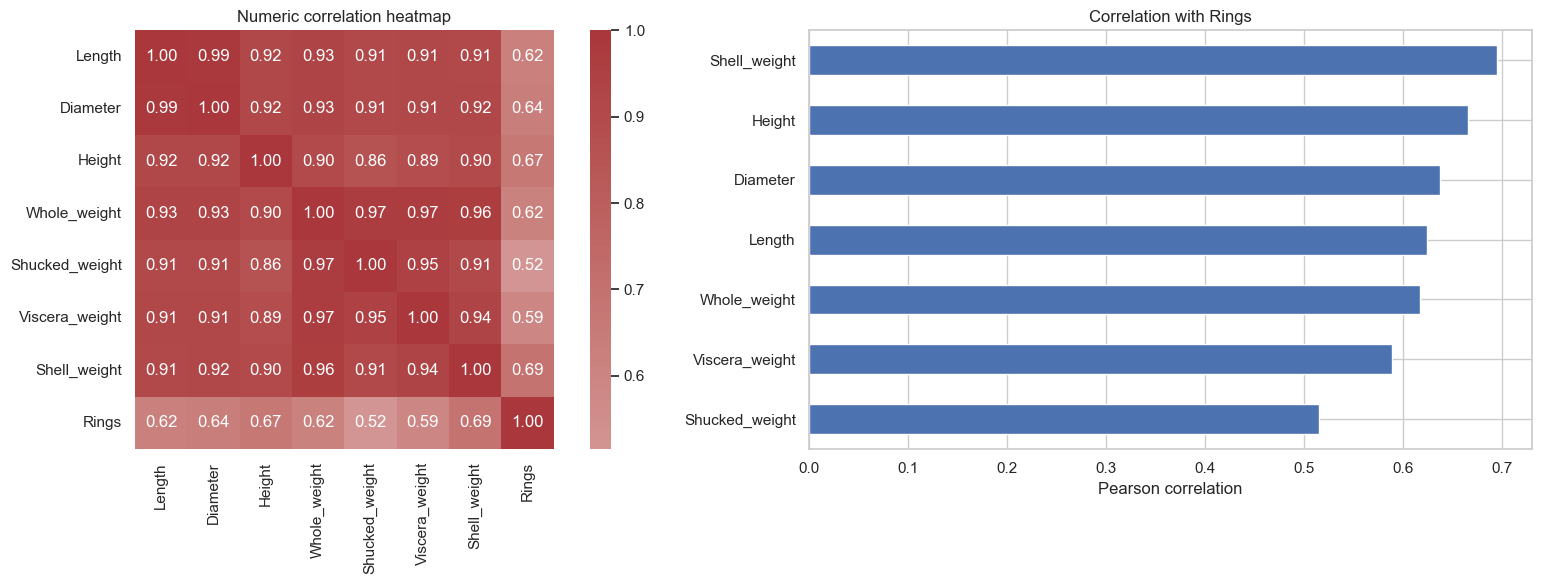

In [9]:
corr = train[num_cols + [TARGET]].corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False).to_frame("corr_with_Rings")

display(target_corr)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=axes[0])
axes[0].set_title("Numeric correlation heatmap")

target_corr.sort_values("corr_with_Rings").plot(kind="barh", legend=False, ax=axes[1])
axes[1].set_title("Correlation with Rings")
axes[1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()


## 7. Outliers and Physical Consistency

`Height = 0`처럼 물리적으로 해석하기 어려운 값은 적지만 존재합니다. 일괄 삭제보다 CV에서 제거/클리핑/그대로 사용을 비교하는 편이 안전합니다.


In [10]:
def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Volume"] = out["Length"] * out["Diameter"] * out["Height"]
    out["Density"] = out["Whole_weight"] / out["Volume"].replace(0, np.nan)
    out["Shucked_ratio"] = out["Shucked_weight"] / out["Whole_weight"].replace(0, np.nan)
    out["Viscera_ratio"] = out["Viscera_weight"] / out["Whole_weight"].replace(0, np.nan)
    out["Shell_ratio"] = out["Shell_weight"] / out["Whole_weight"].replace(0, np.nan)
    out["Shell_to_shucked"] = out["Shell_weight"] / out["Shucked_weight"].replace(0, np.nan)
    return out

train_fe = add_domain_features(train)
test_fe = add_domain_features(test)
ratio_cols = ["Volume", "Density", "Shucked_ratio", "Viscera_ratio", "Shell_ratio", "Shell_to_shucked"]

outlier_checks = pd.DataFrame(
    {
        "train_count": [
            (train["Height"] == 0).sum(),
            (train_fe["Volume"] == 0).sum(),
            (train_fe["Shucked_ratio"] > 1).sum(),
            (train_fe["Viscera_ratio"] > 1).sum(),
            (train_fe["Shell_ratio"] > 1).sum(),
        ],
        "test_count": [
            (test["Height"] == 0).sum(),
            (test_fe["Volume"] == 0).sum(),
            (test_fe["Shucked_ratio"] > 1).sum(),
            (test_fe["Viscera_ratio"] > 1).sum(),
            (test_fe["Shell_ratio"] > 1).sum(),
        ],
    },
    index=["Height == 0", "Volume == 0", "Shucked_ratio > 1", "Viscera_ratio > 1", "Shell_ratio > 1"],
)

display(outlier_checks)
display(train_fe.loc[train_fe["Height"].eq(0), [ID_COL, "Sex", "Length", "Diameter", "Height", "Whole_weight", TARGET]])

display(train_fe[ratio_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,train_count,test_count
Height == 0,6,2
Volume == 0,6,2
Shucked_ratio > 1,41,38
Viscera_ratio > 1,2,2
Shell_ratio > 1,7,9


,id,Sex,Length,Diameter,Height,Whole_weight,Rings
7025,7025,I,0.3150,0.2300,0.0000,0.1340,8
14208,14208,I,0.4300,0.3400,0.0000,0.3440,8
32078,32078,M,0.4700,0.3550,0.0000,0.5785,7
52324,52324,I,0.3150,0.2300,0.0000,0.1340,7
70295,70295,I,0.4300,0.3400,0.0000,0.4060,7
90295,90295,M,0.4300,0.3250,0.0000,0.3335,10


,count,mean,std,min,1%,5%,50%,95%,99%,max
Volume,90615.0000,0.0329,0.0197,0.0000,0.0012,0.0041,0.0323,0.0683,0.0827,0.2975
Density,90609.0000,24.6955,4.0274,2.6211,18.1760,20.1187,24.3284,30.1178,35.8091,495.3560
Shucked_ratio,90615.0000,0.4309,0.0788,0.0517,0.2923,0.3398,0.4315,0.5116,0.5584,4.7826
Viscera_ratio,90615.0000,0.2151,0.0332,0.0052,0.1399,0.1692,0.2138,0.2624,0.3051,1.5000
Shell_ratio,90615.0000,0.2911,0.0469,0.0462,0.2089,0.2339,0.2867,0.3609,0.4151,2.6157
Shell_to_shucked,90615.0000,0.6919,0.1674,0.0606,0.4278,0.4918,0.6667,0.9798,1.1774,10.5000


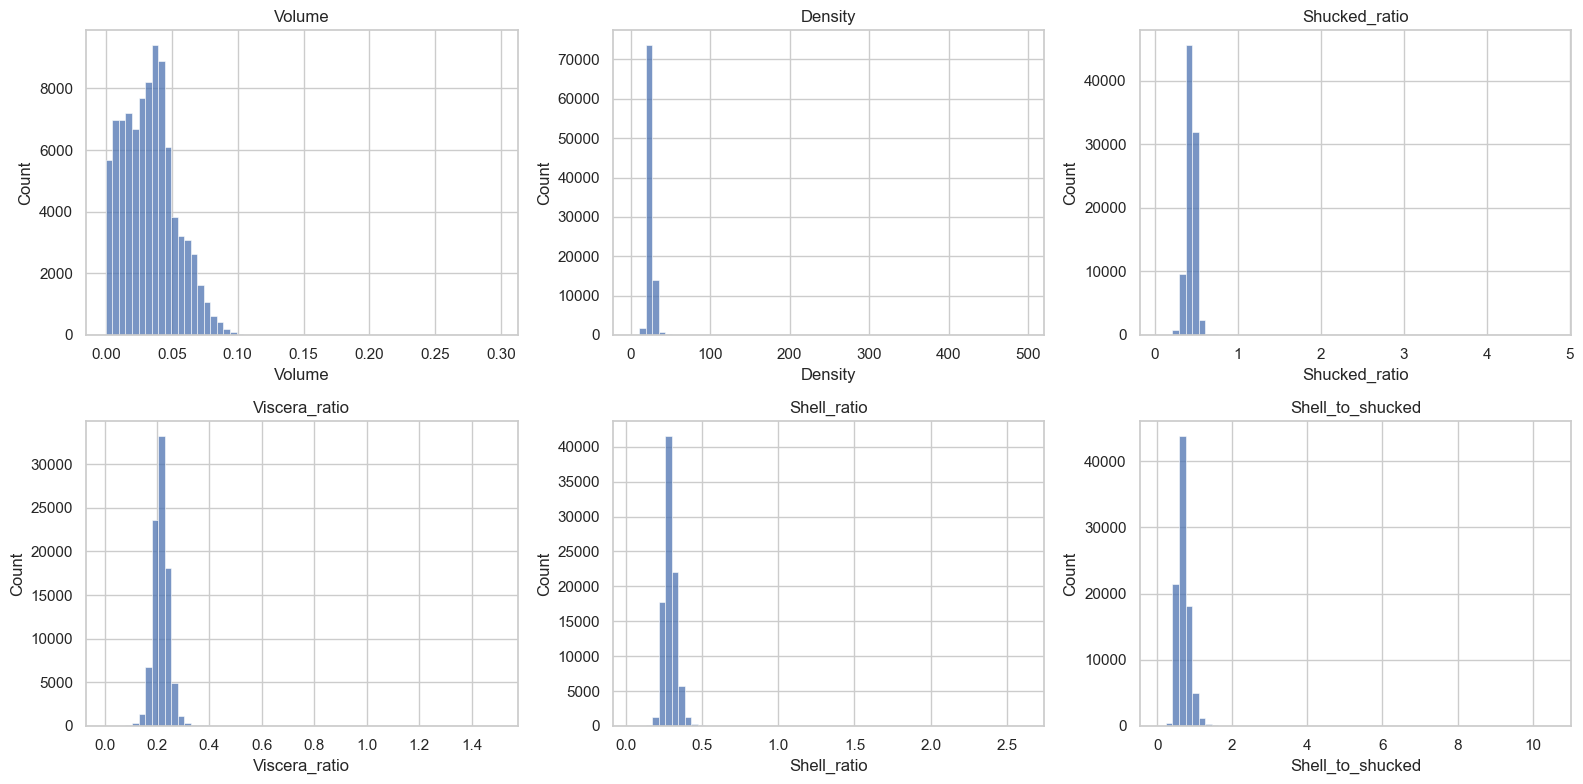

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), ratio_cols):
    sns.histplot(train_fe[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


## 8. Train/Test Drift

테스트 타깃은 없으므로 입력 분포만 비교합니다. 큰 drift가 있으면 validation split 설계나 feature clipping을 조정해야 합니다.


,feature,train_mean,test_mean,std_mean_diff,train_std,test_std,ks_stat
4,Shucked_weight,0.3408,0.3412,0.0022,0.2044,0.2042,0.0033
2,Height,0.1355,0.1358,0.0076,0.0380,0.0382,0.0027
6,Shell_weight,0.2259,0.2261,0.0017,0.1302,0.1298,0.0026
3,Whole_weight,0.7890,0.7901,0.0022,0.4577,0.4576,0.0026
1,Diameter,0.4017,0.4020,0.0029,0.0980,0.0975,0.0025
0,Length,0.5171,0.5174,0.0028,0.1182,0.1176,0.0024
5,Viscera_weight,0.1694,0.1694,-0.0000,0.1009,0.1007,0.0021


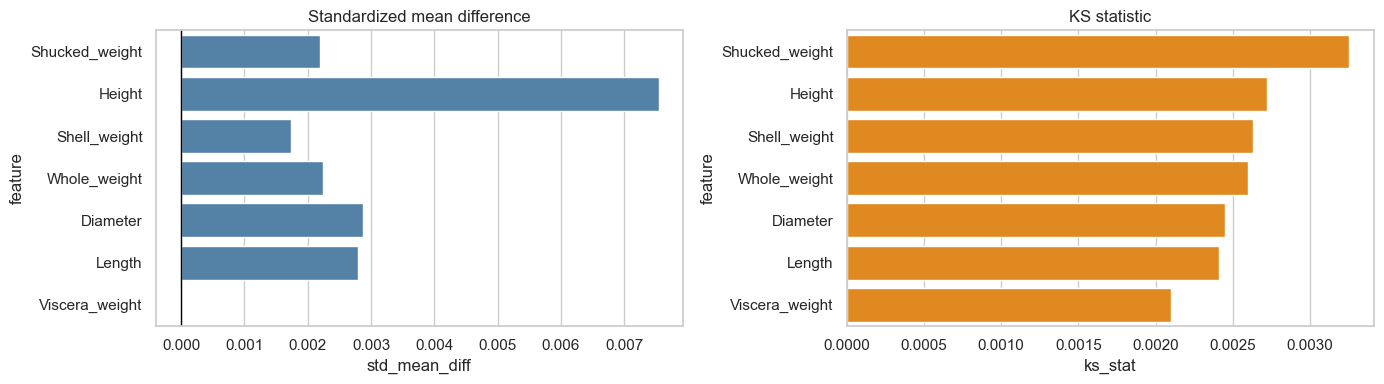

In [12]:
def numeric_drift_table(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        train_values = train_df[col].dropna()
        test_values = test_df[col].dropna()
        train_std = train_values.std(ddof=1)
        standardized_mean_diff = (test_values.mean() - train_values.mean()) / train_std if train_std else np.nan
        ks_stat = ks_2samp(train_values, test_values).statistic if ks_2samp is not None else np.nan
        rows.append(
            {
                "feature": col,
                "train_mean": train_values.mean(),
                "test_mean": test_values.mean(),
                "std_mean_diff": standardized_mean_diff,
                "train_std": train_std,
                "test_std": test_values.std(ddof=1),
                "ks_stat": ks_stat,
            }
        )
    return pd.DataFrame(rows).sort_values("ks_stat", ascending=False)

numeric_drift = numeric_drift_table(train, test, num_cols)
display(numeric_drift)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=numeric_drift, y="feature", x="std_mean_diff", ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Standardized mean difference")

sns.barplot(data=numeric_drift, y="feature", x="ks_stat", ax=axes[1], color="darkorange")
axes[1].set_title("KS statistic")

plt.tight_layout()
plt.show()


## 9. Feature Engineering Candidates

EDA 기준으로는 아래 파생 피처들이 후보입니다. 실제 채택 여부는 cross-validation RMSLE로 결정합니다.

- 크기 조합: `Volume = Length * Diameter * Height`
- 무게 비율: `Shucked_ratio`, `Viscera_ratio`, `Shell_ratio`
- 밀도 계열: `Density = Whole_weight / Volume`
- 범주형 처리: `Sex` one-hot encoding
- 타깃 변환: `log1p(Rings)` 학습 후 `expm1` 복원 비교


,corr_with_Rings
Shell_weight,0.6948
Height,0.6658
Diameter,0.6368
Volume,0.6240
Length,0.6238
Whole_weight,0.6173
Viscera_weight,0.5890
Shucked_weight,0.5151
Shell_to_shucked,0.2517
Shell_ratio,0.1407


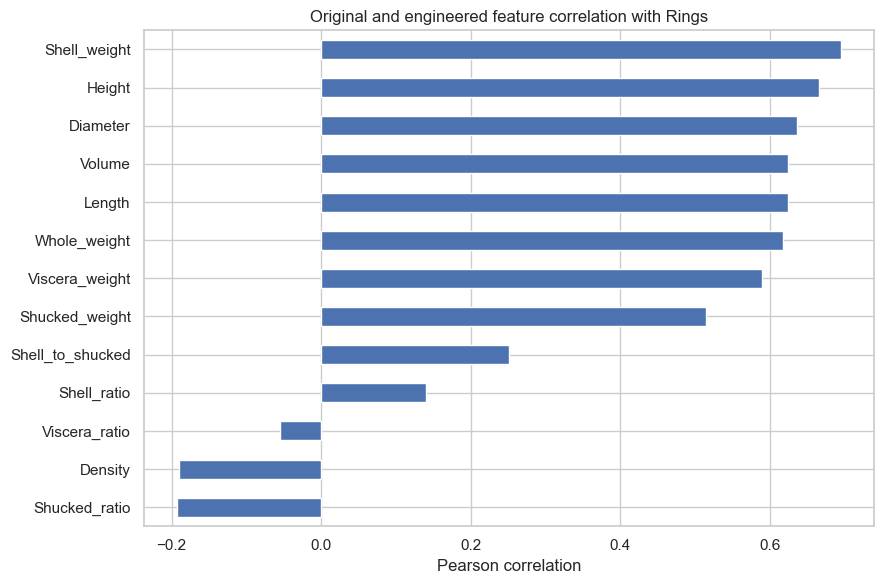

In [13]:
feature_candidate_cols = num_cols + ratio_cols
candidate_corr = (
    train_fe[feature_candidate_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
    .to_frame("corr_with_Rings")
)

display(candidate_corr)

fig, ax = plt.subplots(figsize=(9, 6))
candidate_corr.sort_values("corr_with_Rings").plot(kind="barh", legend=False, ax=ax)
ax.set_title("Original and engineered feature correlation with Rings")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()


## 10. EDA Findings and Next Steps

- 결측치와 중복 행은 없어 기본 정제 비용은 낮습니다.
- `id`는 train/test에서 겹치지 않는 식별자이므로 모델 피처에서 제외합니다.
- `Rings`는 오른쪽 꼬리가 있고 RMSLE로 평가되므로 `log1p(Rings)` 타깃 변환을 baseline에서 비교합니다.
- `Shell_weight`, `Height`, `Diameter`, `Length`, `Whole_weight`가 `Rings`와 강한 양의 상관을 보입니다.
- `Sex`별 `Rings` 분포 차이가 있으므로 one-hot encoding을 기본값으로 둡니다.
- `Height == 0`과 비율 피처의 극단값이 일부 있으므로 제거, 클리핑, 무처리를 CV로 비교합니다.
- train/test 입력 분포 drift는 작아 보이지만, validation은 train 내부에서만 만들고 test 정보는 drift 점검 용도로만 사용합니다.
